In [6]:
import sys
import pandas as pd
from pathlib import Path


def find_experiment_directory(start=Path.cwd()):
    for candidate in (start.resolve(), *start.resolve().parents):
        direct = candidate / "utils.py"
        nested = candidate / "notebooks/illustrating_the_theorem/utils.py"
        if direct.is_file():
            return direct.parent
        if nested.is_file():
            return nested.parent
    raise FileNotFoundError("Could not locate illustrating_the_theorem/utils.py.")


EXPERIMENT_DIRECTORY = find_experiment_directory()
if str(EXPERIMENT_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(EXPERIMENT_DIRECTORY))

In [7]:
sweep_results = pd.read_csv(
    EXPERIMENT_DIRECTORY 
    / "log_volume_ratio_sweep_ot_10000_mc_10000.csv"
)

In [8]:
sweep_summary = (
    sweep_results.groupby(["dimension", "k"])["log_volume_ratio"]
    .agg(
        n_seeds="count",
        mean="mean",
        standard_deviation="std",
        median="median",
        minimum="min",
        maximum="max",
    )
    .reset_index()
)
display(sweep_summary)

,dimension,k,n_seeds,mean,standard_deviation,median,minimum,maximum
0,2,2.0,10,-0.013835,0.016296,-0.015370,-0.042833,0.014997
1,2,4.0,10,-0.022323,0.015631,-0.023356,-0.047003,0.006658
2,2,8.0,10,-0.037647,0.018571,-0.040546,-0.072051,-0.003150
3,2,16.0,10,-0.057324,0.018263,-0.058887,-0.093888,-0.022856
4,2,32.0,10,-0.085674,0.022776,-0.085321,-0.125788,-0.039843
5,2,64.0,10,-0.133462,0.020112,-0.130430,-0.174888,-0.096091
6,4,2.0,10,-1.363830,0.110054,-1.383491,-1.500542,-1.190540
7,4,4.0,10,-1.565825,0.127019,-1.533707,-1.807602,-1.366170
8,4,8.0,10,-1.788380,0.127992,-1.763605,-1.976355,-1.611665
9,4,16.0,10,-1.914860,0.123255,-1.910927,-2.112029,-1.696610


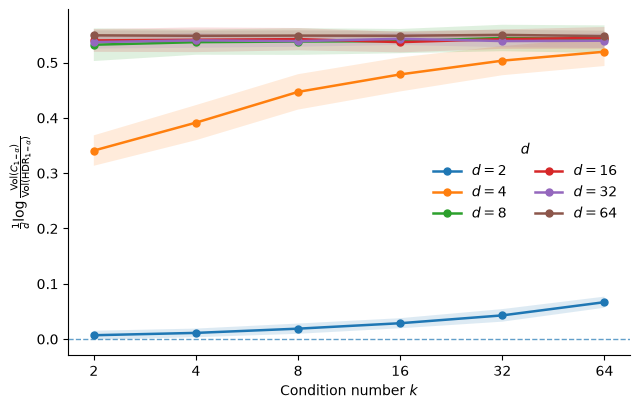

In [10]:
import numpy as np
import matplotlib.pyplot as plt

plot_df = sweep_summary.copy()

sweep_results["scaled_log_volume_gap"] = (
    -sweep_results["log_volume_ratio"]
    / sweep_results["dimension"]
)

scaled_summary = (
    sweep_results
    .groupby(["dimension", "k"])["scaled_log_volume_gap"]
    .agg(
        n_seeds="count",
        mean="mean",
        standard_deviation="std",
        median="median",
        minimum="min",
        maximum="max",
    )
    .reset_index()
)

# Dimension-normalized log-volume gap:
# (1 / d) * log(Vol(C) / Vol(HDR))
plot_df["scaled_mean"] = -plot_df["mean"] / plot_df["dimension"]
plot_df["scaled_std"] = (
    plot_df["standard_deviation"] / plot_df["dimension"]
)
fig, ax = plt.subplots(figsize=(6.5, 4.2))

for dimension, group in scaled_summary.groupby("dimension"):
    group = group.sort_values("k")

    ax.plot(
        group["k"],
        group["mean"],
        marker="o",
        linewidth=1.8,
        markersize=5,
        label=fr"$d={dimension}$",
    )

    ax.fill_between(
        group["k"],
        group["mean"] - group["standard_deviation"],
        group["mean"] + group["standard_deviation"],
        alpha=0.15,
    )

ax.axhline(0, linestyle="--", linewidth=1, alpha=0.7)

ax.set_xscale("log", base=2)
ax.set_xticks([2, 4, 8, 16, 32, 64])
ax.set_xticklabels([2, 4, 8, 16, 32, 64])

ax.set_xlabel(r"Condition number $k$")
ax.set_ylabel(
    r"$\frac{1}{d}\log\frac{\mathrm{Vol}(C_{1-\alpha})}"
    r"{\mathrm{Vol}(\mathrm{HDR}_{1-\alpha})}$"
)

ax.legend(title=r"$d$", frameon=False, ncol=2)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
plt.show()